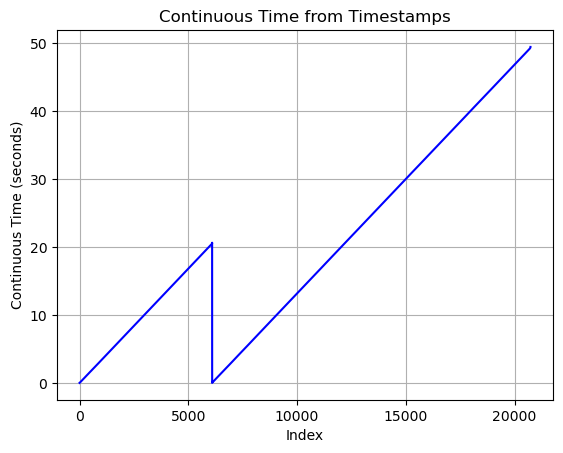

First few continuous time values:
[0.       0.       0.0008   0.009289 0.010015 0.011481 0.019094 0.020007
 0.022162 0.028899]


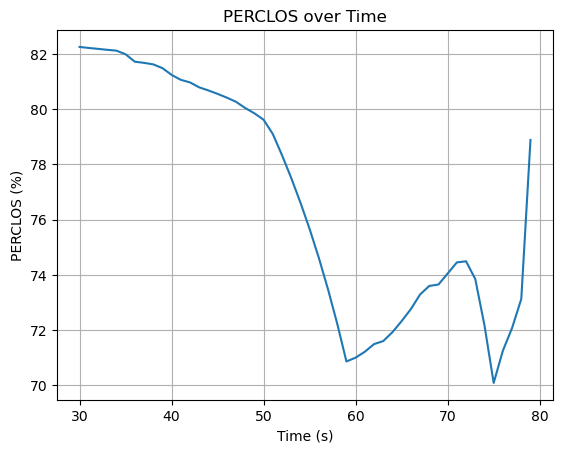

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Excel file
filename = r'C:\Users\hp\Desktop\Eye tracking Literature\tobii data\original_helena_EO_EC.xlsx'
data = pd.read_excel(filename)

# Convert timestamps from microseconds to continuous time in seconds
timestamps_us = data.iloc[:, 0].values  # Adjust column index if needed
timestamps_sec = timestamps_us / 1e6
continuous_time = timestamps_sec - timestamps_sec[0]  # zero-based time

# Plot continuous time vs index
plt.figure()
plt.plot(np.arange(len(continuous_time)), continuous_time, 'b')
plt.xlabel('Index')
plt.ylabel('Continuous Time (seconds)')
plt.title('Continuous Time from Timestamps')
plt.grid(True)
plt.show()

# Display first 10 continuous time values
print("First few continuous time values:")
print(continuous_time[:10])

# Extract relevant pupil diameter and validity columns
pupil_left = pd.to_numeric(data.iloc[:, 35], errors='coerce')   # Column 36
pupil_right = pd.to_numeric(data.iloc[:, 36], errors='coerce')  # Column 37
validity_left = pd.to_numeric(data.iloc[:, 37], errors='coerce')  # Column 38
validity_right = pd.to_numeric(data.iloc[:, 38], errors='coerce') # Column 39

# Detect eye closure: both eyes are either invalid, missing, or have zero pupil size
eye_closed = (
    (pupil_left.isna() | (pupil_left == 0) | (validity_left > 1)) &
    (pupil_right.isna() | (pupil_right == 0) | (validity_right > 1))
).astype(int)

# Set sliding window parameters (60s window, 1s step)
window_size = 60  # seconds
step_size = 1     # seconds

# Create list of time points for the sliding window
start_time = timestamps_sec[0]
end_time = timestamps_sec[-1]
time_points = np.arange(start_time, end_time, step_size)

# Initialize lists to store PERCLOS values and times
perclos_values = []
perclos_time = []

# Calculate PERCLOS in each sliding window
for t in time_points:
    t_start = t
    t_end = t + window_size
    indices = (timestamps_sec >= t_start) & (timestamps_sec < t_end)
    
    if np.sum(indices) > 0:
        perclos = np.sum(eye_closed[indices]) / np.sum(indices)
        perclos_values.append(perclos)
        perclos_time.append(t_start + window_size / 2)  # center of window
    else:
        perclos_values.append(np.nan)
        perclos_time.append(t_start + window_size / 2)

# Plot PERCLOS over time
plt.figure()
plt.plot(perclos_time, np.array(perclos_values) * 100)
plt.xlabel('Time (s)')
plt.ylabel('PERCLOS (%)')
plt.title('PERCLOS over Time')
plt.grid(True)
plt.show()
